In [9]:
import numpy as np
import sympy
from sympy import symbols, Eq, linear_eq_to_matrix
import random
import matplotlib.pyplot as plt
from collections import deque, defaultdict
# from pyeda.inter import expr, exprvar, expr2bdd
# from dd.autoref import BDD
import networkx as nx
from matplotlib.colors import ListedColormap
import itertools
import pandas as pd
from sympy.logic.boolalg import SOPform
import re
import pickle
import datetime
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from itertools import product
import seaborn as sns
from collections import deque


# change the code to save the data in sqlite database or pickle file to store the results
    # store number of devices in each path
    # Store currents in each path for future plots

#make code run in hipergator

#run upto 3-bit adder for optimal solution with 10 iterations and generate graphs

#############################################################################

#find and pinpoint cases that get only max zeros and min ones current

# 1 - (number of devices)
# 0 - (neighbour lrs devices to ground)
# run the simulation for only those special cases
import sys
import os
import importlib

In [10]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

In [11]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

# fails = ['apex4'] #revlib
# benchmark_lst = ["in0", "apex2", "misex3", "pdc", "seq", "spla", "tial", "cps", "apex5", "bw", "frg1"]  #revlib
benchmark_lst = ["frg1"]  #revlib
directory = 'revlib'

# benchmark_lst = ["c499"]  #iscas85
# directory = 'iscas85'

filename_lst = {benchmark:f"../bdds/benchmarks/{directory}/"+benchmark_lst[i]+".sbdd" for i, benchmark in enumerate(benchmark_lst)}

# benchmark_lst = ['3-bitAdder']
# filename_lst = {str(i)+"-bitAdder":"../bdds/"+str(i)+"-bitAdder.sbdd" for i in range(1, 18+1)}

Functional_Logic_Of_Path_Crossbar_Programings = {}
for benchmark in benchmark_lst:
    start_time = time.time()
    # filename = filename_lst[str(adderbit)+'-bitAdder']
    filename = filename_lst[benchmark]

    # if(adderbit<10):
    #     outputs, df = truth_tables_data[str(adderbit)+'-bitAdder']["outputs"], truth_tables_data[str(adderbit)+'-bitAdder']["TruthTable_df"]
    # else:
    #     outputs, df = None, None
        
    path = PATH(CrossbarGridSize = 64)
    # path.TruthTable_to_BooleanExpression(df, outputs=outputs)
    # path.BooleanExpresions_to_BDD()
    # print("----------------------------------------------------------------------------------------------")
    # expressions = {'F0' : '(a & b) | (a & cin) | (b & cin)',
    # 'F1' : '(a & b & cin) | (a & ~b & ~cin) | (b & ~a & ~cin) | (cin & ~a & ~b)'}
    # variables = ['a', 'b', 'cin']
    # path.SetBooleanExpressionsAndVaribles(variables = variables, expressions = expressions, outputs = list(expressions.keys()))
    # print("----------------------------------------------------------------------------------------------")
    
    # path.SetBooleanExpressionsAndVaribles(variables = None, expressions = None, outputs = outputs, OriginalTruthTable=df)
    path.parse_file_to_NetworkXGraph(filename)
    path.BDD_to_NetworkXGraph()
    # if(adderbit<5):
    #     path.Verify_BDD_to_NetworkXGraph(withExpression=False, withOriginalTruthTable=False, generateFromBDD=True)
    # path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphPreprocessing()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphTransformation()
    # path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")
    print('transformation done...')
    path.GraphCompression()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")
    print('Compression done...')
    
    path.GraphSplittingWithHeightConstraint(height=6)
    print('Height Constraint...')
    
    path.GraphSplittinWithSizeConstraint(size=64)
    print('Size Constraint...')
    
    path.CrossbarDesignRelalization()

    # path.InferPrerequisiteTrees()

    # print('path.Processed_graphs_Map', path.Processed_graphs_Map.keys())

    # print('path.Processed_graphs_Map[None]',path.Processed_graphs_Map[None])

    # print('path.output_node_index',path.output_node_index)

    # rows, cols, count = 0, 0, 0
    # dimMap = {}
    # for key in path.Processed_graphs_Map:
    #     row = len(path.Processed_graphs_Map[key]['Crossbar_design'])
    #     col = len(path.Processed_graphs_Map[key]['Crossbar_design'][0])

    #     if(f'{row}x{col}' not in dimMap):
    #         dimMap[f'{row}x{col}'] = 0
    #     dimMap[f'{row}x{col}']+=1
    #     rows+=row
    #     cols+=col
    #     count+=1

    # print('Total = rows x cols:', rows,"x", cols, "count:", count)
    # print(dimMap)

    # Functional_Logic_Of_Path_Crossbar_Programings[str(adderbit)+'-bitAdder'] = {'Crossbar':path.CrossbarResistiveStates, 'Bitlines':path.Bitlines, 'TruthTable':path.OriginalTruthTable, 'OutputLine_Map':path.OutputLine_Map, 'AdderBit':str(adderbit)+'-bitAdder', 'SBDD (V x E)':path.SBDD_dimentions}
    
    print(f"{benchmark} took {time.time() - start_time:.6f} seconds")

    # print('path.CrossbarLongPaths',path.CrossbarLongPaths)
    print("_________________________________________________________________________")
    # if(benchmark==benchmark):
    #     break

# Save (pickle) to a file
# with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "wb") as f:
#     pickle.dump(Functional_Logic_Of_Path_Crossbar_Programings, f)
# print("Data saved to multi_data.pkl")  #nithin

transformation done...
Compression done...
Height Constraint...
Size Constraint...
frg1 took 0.546567 seconds
_________________________________________________________________________


In [ ]:
18106

In [205]:
# for design_id_group in path.Processed_group_graphs_Map:
#     for outputLabel in path.Processed_group_graphs_Map[design_id_group]['Crossbar_disabledOutputsToInputs']:
#         print(path.Processed_group_graphs_Map[design_id_group]['Crossbar_disabledOutputsToInputs'][outputLabel]['disjoint_cells_to_be_added'])
#         print()

220 in_split_ids {'8cca5f52-f308-47fa-98d5-f3f66b85f4c4'}
O151 out_split_id e6360ea4-5be9-448a-a63d-513f534098ed
219 in_split_ids {'985ac453-7ece-4f31-9cfe-7b231e6dae24'}
93 in_split_ids {'b26f3ad3-2bec-4578-8f3a-e4d9630e0c8c'}
O170 out_split_id e0ac34b7-1cbb-4e31-97a1-41f390e76986
210 in_split_ids {'edf5efd5-391f-4b43-ba4b-7817ab164ba5'}
97 in_split_ids {'afae338c-a2e2-4ffa-a7fe-24941dfc5f94'}
305 in_split_ids {'db8d8769-034d-436a-80e6-0097e8cff863'}
207 in_split_ids {'a8389e56-946d-45eb-a338-f663b0148a58'}
201 in_split_ids {'e2a77f5d-a7ea-4451-8c07-84c9d0d862a4'}
O146 out_split_id 5b20cd27-a219-450e-be39-d0826f0f8bdc
319 in_split_ids {'96c445bb-e22a-4fc5-a520-356626df5d99'}
O154 out_split_id 30b005f8-18a2-4de2-99ea-745be3e144da
314 in_split_ids {'4b2ef965-4423-4b5e-95cb-d796266faa72'}
216 in_split_ids {'d1092ce7-5774-405b-a995-c2481621972e'}
135 in_split_ids {'bbdbf488-cb16-4b9e-a4e5-f200e6c863e2'}
O140 out_split_id d5c98306-4f91-4254-9340-9771374e2eca
130 in_split_ids {'fe3f8f0e-3ae

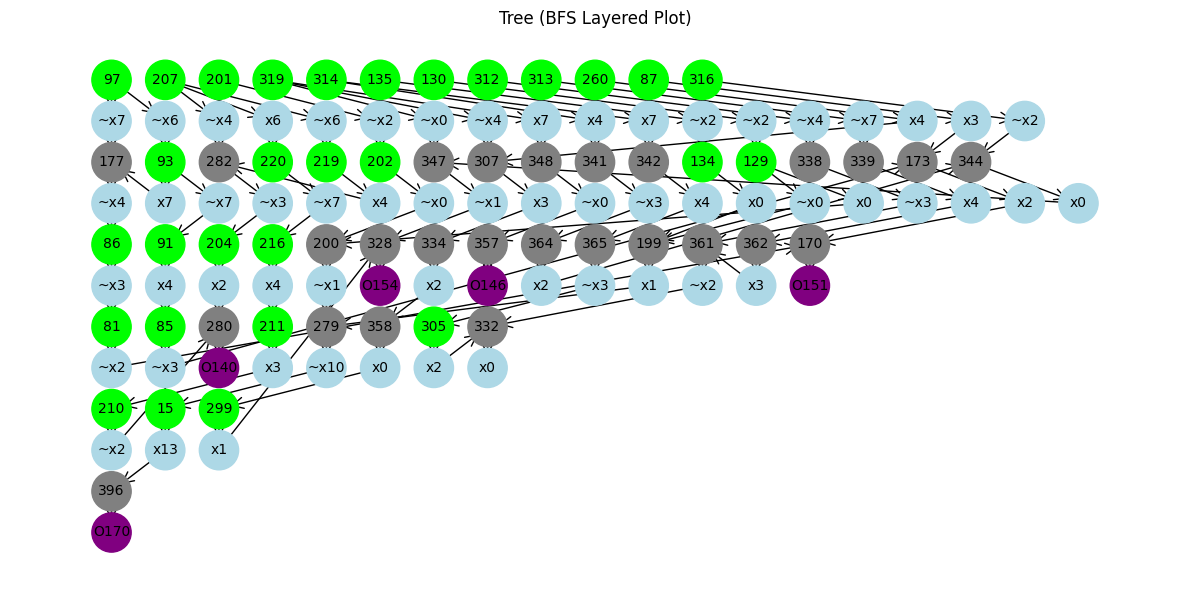

In [255]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def plot_tree_bfs_layered(G, node_labels=True, edge_labels=False, title="Tree (BFS Layered Plot)", debug=False):
    # Step 1: Find the root node (U1 node with no predecessors)
    # Step 1: Find all root nodes (U1 nodes with no predecessors)
    roots = [
        node for node in G.nodes
        if G.nodes[node].get("BipartitePart") == "U1" and G.in_degree(node) == 0
    ]
    if not roots:
        raise ValueError("No root nodes found (U1 nodes with no predecessors)")

    # Step 2: BFS from all roots to assign levels
    levels = {root: 0 for root in roots}
    layer_nodes = defaultdict(list)
    queue = deque(roots)

    for root in roots:
        layer_nodes[0].append(root)

    while queue:
        node = queue.popleft()
        level = levels[node]

        for succ in G.successors(node):
            if succ not in levels:
                levels[succ] = level + 1
                layer_nodes[level + 1].append(succ)
                queue.append(succ)

    # Step 3: Assign positions
    pos = {}
    x_gap = 2.5
    y_gap = 1.5
    for level, nodes in layer_nodes.items():
        for i, node in enumerate(nodes):
            pos[node] = (i * x_gap, -level * y_gap)

    # Step 4: Assign positions to unplaced nodes (unreachable from root)
    unplaced_nodes = [node for node in G.nodes if node not in pos]
    if unplaced_nodes:
        extra_level = max(layer_nodes.keys(), default=0) + 1
        for i, node in enumerate(unplaced_nodes):
            pos[node] = (i * x_gap, -extra_level * y_gap)

    # Step 5: Determine node colors
    node_colors = []
    for node in G.nodes:
        if node in unplaced_nodes:
            node_colors.append('red')
        else:
            literal = G.nodes[node].get('literal', '')
            in_split_ids = G.nodes[node].get('in_split_id',set())
            out_split_id = G.nodes[node].get('out_split_id',None)
            if(in_split_ids != set()):
                if(debug):
                    print(literal, 'in_split_ids',in_split_ids)
            if(out_split_id != None):
                if(debug):
                    print(literal, 'out_split_id',out_split_id)
            if out_split_id != None:
                node_colors.append('purple')
            elif len(in_split_ids)>0:
                node_colors.append('lime')
            elif 'O' in literal:
                node_colors.append('orange')
            elif literal.isdigit():
                node_colors.append('grey')
            else:
                node_colors.append('lightblue')

    # Step 6: Draw the graph
    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20)

    if node_labels:
        labels = {n: G.nodes[n].get('literal', str(n)) for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels, font_size=10)

    if edge_labels:
        edge_lbls = {(u, v): d.get('condition', '') for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_lbls, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for i,key in enumerate(path.Processed_group_graphs_Map):
    # if(i not in [2,4,5,7,9,10,11,12]):
    #     continue
    # for row in path.Processed_graphs_Map[key]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[key]['Selector_Lines_Map'])
    # print(key, i)
    # print(path.Processed_group_graphs_Map[key]['OutputLine_group_Map'])
    # print(key)
    if(i!=11):
        continue
    plot_tree_bfs_layered(
        path.Processed_group_graphs_Map[key]['processed_group_graph'],
        debug=True
    )

In [323]:
len(path.Processed_group_graphs_Map)

8

In [324]:
# First import the module in a normal way:
import PathDesignLogicalVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignLogicalVerification)
from PathDesignLogicalVerification import PATH_Design_Logic_Verification, Bus

# for node in path.Processed_group_graphs_Map:
#     # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
#     #     print(row)
#     # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
#     # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
#     # print()
#     # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
#     # print(path.Processed_graphs_Map[node]['LongestPath'])
#     # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
#     # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
#     print('------------------------------------------------')

CrossbarGridSize = 64

bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)



total_rows = 0
total_cols = 0
Processed_group_graphs_Map = {}
for design_ID in path.Processed_group_graphs_Map:
    m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
    n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
    if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
        Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
        total_rows += m
        total_cols += n
    else:
        path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
        Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
if(len(Processed_group_graphs_Map)):
    path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

print('NumberOfDesigns:', bus.getNumberOfDesigns())
print('NumberOfCrossbars:', bus.getNumberOfCrossbars())

test_results = bus.RunRandomTestCases(num_tests=10, RunAllTests=False)
# print()
# test_results = bus.RunRandomTestCasesOnEachDesign(1)

# OutputLine_group_selectorLines_Map
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# GoldenModelOutputMap['f63']

NumberOfDesigns: 8
NumberOfCrossbars: 7
______________________________________
[✅] Test 1 Passed {'f2': 0, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 2 Passed {'f2': 0, 'f1': 0, 'f0': 0}
______________________________________
______________________________________
[✅] Test 3 Passed {'f2': 0, 'f1': 0, 'f0': 1}
______________________________________
______________________________________
[✅] Test 4 Passed {'f2': 0, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 5 Passed {'f2': 0, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 6 Passed {'f2': 0, 'f1': 1, 'f0': 0}
______________________________________
______________________________________
[✅] Test 7 Passed {'f2': 1, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 8 Passed {'f2': 0, 'f1': 1, 'f0': 1}
_______

In [287]:
failed_cases = []
n = len(test_results)

for i in range(n):
    model_output = test_results[i]['model_output']
    golden_output = test_results[i]['golden_output']
    if(golden_output!=model_output):
        failed_cases.append(test_results[i])

print(len(failed_cases))
#f6 f10

0


In [288]:
falsePositive = 0
for failed_case in failed_cases:
    OutputMap = failed_case['model_output']
    GoldenModelOutputMap = failed_case['golden_output']
    flag=True
    for key in OutputMap:
        if(OutputMap[key]!=GoldenModelOutputMap[key]):
            if(OutputMap[key]==1 and flag):
                falsePositive+=1
                flag=False
            # print(f'missmatch at {key}')
            # print(f'OutputMap[key]!=GoldenModelOutputMap[key]')
            # print(f'{OutputMap[key]}!={GoldenModelOutputMap[key]}')
falsePositive

0

In [661]:
# outputOfTree, results = bus.RunTestCasesOnDesignTrees({'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1})

# for design_ID_group in results:
#     output_map = results[design_ID_group][0]
#     path_map = results[design_ID_group][1]
#     intersectionToNodeId = results[design_ID_group][2]
#     if('f58' in output_map and output_map['f58']):
#         endPath = path_map['f58']
#         endPath_design_ID_group = design_ID_group
#         break
# # print('outputOfTree', outputOfTree)
# endPath

In [662]:
# bus.crossbar_designs[endPath_design_ID_group]['processed_group_graph'].nodes['16956']
# bus.crossbar_designs[endPath_design_ID_group]['processed_group_graph'].nodes['EdgeNode_1726']

In [663]:
# def findEndNode(endPath_temp):
#     for design_ID_group in results:
#         intersectionToNodeId = results[design_ID_group][2]
    
#         start_endNode = endPath_temp[0]
#         for splitIDSet, WordLineNodeID in intersectionToNodeId.items():
#             if(WordLineNodeID == start_endNode):
#                 InSplitIDs = splitIDSet
                
#                 return InSplitIDs

# def findGraphWithOutSplitID(findingOutSplitIDs):
#     graphandOutputNode = []
#     for design_ID in path.Processed_group_graphs_Map:
#         processed_group_graph = path.Processed_group_graphs_Map[design_ID]['processed_group_graph']
#         for node in processed_group_graph.nodes:
#             if(processed_group_graph.nodes[node]['out_split_id'] in findingOutSplitIDs):
#                 literal = processed_group_graph.nodes[node]['literal']
#                 out_split_id = processed_group_graph.nodes[node]['out_split_id']
#                 graphandOutputNode.append((design_ID, processed_group_graph, node, literal, out_split_id))
#     return graphandOutputNode

# def findIntermediatePath(graphandOutputNode):
#     design_ID_group_curr = graphandOutputNode[0]
#     graph = graphandOutputNode[1]
#     nodeID = graphandOutputNode[2]
#     literal = graphandOutputNode[3]
#     out_split_id = graphandOutputNode[4]

#     path_map = results[design_ID_group_curr][1]

#     print(graph.nodes['1467_ID'])
#     print(graph.nodes['EdgeNode_2722'])
    
#     return path_map[out_split_id]
    
# print(endPath)
# InSplitIDs = findEndNode(endPath)
# # print('InSplitIDs',InSplitIDs)
# graphandOutputNode = findGraphWithOutSplitID(InSplitIDs)
# findIntermediatePath(graphandOutputNode[0])

In [664]:
# nodesPath = ['7397', 'EdgeNode_2387', '10114', 'EdgeNode_2355', '19527', 'EdgeNode_2214']
# for node in nodesPath:
#     print(bus.MainBDD_For_GoldenModel.nodes[node]['literal'])

In [665]:
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# GoldenModelOutputMap['f58']

In [666]:
# input_assignment['x1']

In [667]:
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# OutputMap = bus.ExecuteDesignsInTopologicalOrder(input_assignment)
# print(OutputMap)
# print()
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# print(GoldenModelOutputMap)
# print()
# for key in OutputMap:
#     if(OutputMap[key]!=GoldenModelOutputMap[key]):
#         print(f'missmatch at {key}')
#         print(f'OutputMap[key]!=GoldenModelOutputMap[key]')
#         print(f'{OutputMap[key]}!={GoldenModelOutputMap[key]}')

In [668]:
# [bus.MainBDD_For_GoldenModel.nodes[node]['literal'] for node in pathsMap['f67']]

In [669]:
# bus.MainBDD_For_GoldenModel.nodes[pathsMap['f58'][4]]

In [670]:
def binary_dict_to_str(d, prefix, length):
    """Extract bits with a given prefix and return as a binary string (MSB to LSB)."""
    return ''.join(str(d[f"{prefix}{i}"]) for i in reversed(range(length)))

def run_adder_tests(test_results):
    for test in test_results:
        input_data = test['input']
        
        # Determine the bit width (e.g., a0–a4 → 5 bits)
        a_keys = [k for k in input_data if k.startswith("a")]
        b_keys = [k for k in input_data if k.startswith("b")]
        bit_width = max(int(k[1:]) for k in a_keys + b_keys) + 1
        
        a_bin = binary_dict_to_str(input_data, 'a', bit_width)
        b_bin = binary_dict_to_str(input_data, 'b', bit_width)
        cin_bin = str(input_data['cin'])

        # Run adder
        total = int(a_bin, 2) + int(b_bin, 2) + int(cin_bin, 2)
        sum_bin = bin(total)[2:].zfill(bit_width + 1)  # +1 for possible carry out

        # Extract sum and cout from result
        sum_bits = list(reversed(sum_bin[-bit_width:]))  # sum0 = LSB
        cout = int(sum_bin[:-bit_width] or '0')

        # Format result to compare with golden_output
        computed_output = {f"sum{i}": int(bit) for i, bit in enumerate(sum_bits)}
        computed_output["cout"] = cout

        match = computed_output == test['golden_output']
        
        print(f"Test {test['test_id']}:", "✅ Match" if match else "❌ Mismatch")
        if not match:
            print(f"  Input:      a={a_bin}, b={b_bin}, cin={cin_bin}")
            print(f"  Computed:   {computed_output}")
            print(f"  Expected:   {test['golden_output']}")
            print()
            
# run_adder_tests(test_results)

In [360]:
# First import the module in a normal way:
import PathDesignAnalogVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignAnalogVerification)
from PathDesignAnalogVerification import PATH_Design_Analog_Verification, Bus

# for node in path.Processed_group_graphs_Map:
#     # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
#     #     print(row)
#     # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
#     # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
#     # print()
#     # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
#     # print(path.Processed_graphs_Map[node]['LongestPath'])
#     # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
#     # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
#     print('------------------------------------------------')

CrossbarGridSize = 64
bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
total_rows = 0
total_cols = 0
Processed_group_graphs_Map = {}
for design_ID in path.Processed_group_graphs_Map:
    m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
    n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
    if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
        Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
        total_rows += m
        total_cols += n
    else:
        path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
        Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
if(len(Processed_group_graphs_Map)):
    path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

bus.CalibrateHRSValues(Optimisation=True, max_iterations=1) #nithin

missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
guardBound 0.013972159752400246
R_HRS 1000000000.0
design_ID_group (frozenset(), 0)
WordLineInputs_zero [0]
ZerosCurrent 1.9215179857445856e-05
OnesCurrent 0.013991374932257692
best_R_HRS: 1000000000.0 best_guardBound: 0.013972159752400246

0 design is complete
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
missing []
m

In [19]:
# First import the module in a normal way:
import PathDesignAnalogVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignAnalogVerification)
from PathDesignAnalogVerification import PATH_Design_Analog_Verification, Bus

# for node in path.Processed_group_graphs_Map:
#     # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
#     #     print(row)
#     # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
#     # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
#     # print()
#     # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
#     # print(path.Processed_graphs_Map[node]['LongestPath'])
#     # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
#     # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
#     print('------------------------------------------------')

CrossbarGridSize = 64
bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
total_rows = 0
total_cols = 0
Processed_group_graphs_Map = {}
for design_ID in path.Processed_group_graphs_Map:
    m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
    n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
    if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
        Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
        total_rows += m
        total_cols += n
    else:
        path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
        Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
if(len(Processed_group_graphs_Map)):
    path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

bus.CalibrateHRSValues(Optimisation=True, max_iterations=10) #nithin

guardBound 0.013969761584546377
R_HRS 1000000000.0
guardBound 0.013948190523836643
R_HRS 500000000.0
guardBound 0.013905106070586586
R_HRS 250000000.0
guardBound 0.013819166825356362
R_HRS 125000000.0
guardBound 0.013648198996845811
R_HRS 62500000.0
guardBound 0.013309843361151692
R_HRS 31250000.0
guardBound 0.012646969983462701
R_HRS 15625000.0
guardBound 0.011372995713523897
R_HRS 7812500.0
guardBound 0.0090073395921191
R_HRS 3906250.0
guardBound 0.004853251896049465
R_HRS 1953125.0
design_ID_group (frozenset(), 0)
WordLineInputs_zero [0]
ZerosCurrent 0.009138123036208172
OnesCurrent 0.013991374932257637
best_R_HRS: 1953125.0 best_guardBound: 0.004853251896049465

0 design is complete
guardBound 0.01397216436572373
R_HRS 1000000000.0
guardBound 0.013952994216637411
R_HRS 500000000.0
guardBound 0.013914713395417213
R_HRS 250000000.0
guardBound 0.01383838858622563
R_HRS 125000000.0
guardBound 0.013686677803164753
R_HRS 62500000.0
guardBound 0.013386944938874556
R_HRS 31250000.0
guardBo

In [20]:
# test_results = bus.RunRandomTestCases(num_tests=40, RunAllTests=True)
test_results = bus.RunRandomTestCases(num_tests=10, RunAllTests=False)

lst0 = []
lst1 = []

failuresOfWorstcase0 = 0
failuresOfWorstcase1 = 0

tolerance1 = 1e-6
tolerance0 = 0

currentFlag = False
for design_ID in bus.OnesCurrentFromDesignMap:
    minOnesCurrent = min(bus.OnesCurrentFromDesignMap[design_ID],default=1)
    maxZerosCurrent = max(bus.ZerosCurrentFromDesignMap[design_ID],default=0)
    print()
    print(f"maxZerosCurrent: {maxZerosCurrent}")
    print(f"minOnesCurrent: {minOnesCurrent}")
    lst0.append(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID])
    if(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID]>tolerance0):
        print(f"Worst case approximation is not working 0 for {design_ID}")
        print(f"{bus.WorstCaseMaxZero[design_ID]} < {maxZerosCurrent}")
        print("worst max 0 < current") 
        failuresOfWorstcase0+=1

    lst1.append(bus.WorstCaseMinOne[design_ID]-minOnesCurrent)
    if(bus.WorstCaseMinOne[design_ID]-minOnesCurrent>tolerance1):
        print(f"Worst case approximation is not working 1 for {design_ID}")
        print(f"{bus.WorstCaseMinOne[design_ID]} > {minOnesCurrent}")
        print("worst min 1 > current")
        failuresOfWorstcase1+=1
    
    if(minOnesCurrent<maxZerosCurrent):
        currentFlag = True
        print(f'Have an issue at {design_ID}')

if(currentFlag):
    print("\nNot good 😡")
else:
    print("\ngood 😁")

______________________________________
[✅] Test 1 Passed {'f2': 0, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 2 Passed {'f2': 0, 'f1': 1, 'f0': 0}
______________________________________
______________________________________
[✅] Test 3 Passed {'f2': 0, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 4 Passed {'f2': 0, 'f1': 1, 'f0': 0}
______________________________________
______________________________________
[✅] Test 5 Passed {'f2': 0, 'f1': 1, 'f0': 0}
______________________________________
______________________________________
[✅] Test 6 Passed {'f2': 1, 'f1': 1, 'f0': 0}
______________________________________
______________________________________
[✅] Test 7 Passed {'f2': 1, 'f1': 1, 'f0': 1}
______________________________________
______________________________________
[✅] Test 8 Passed {'f2': 0, 'f1': 0, 'f0': 1}
______________________________________
________

In [22]:
min(lst0), min(lst1)

(np.float64(-0.004034201404144195), np.float64(-0.07304026367744679))

In [21]:
failuresOfWorstcase0, failuresOfWorstcase1

(0, 0)

In [93]:
MultiplexedCrossbar = [
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
]
MultiplexedCrossbar = np.array(MultiplexedCrossbar)
wordLineInputs = [24]
outputBitlineIndex = 40

In [107]:
mainpath = [
    (24,33),
    (26,33),
    (26,35),
    (29,35),
    (29,40),
]
for i in range(len(MultiplexedCrossbar)):
    for j in range(len(MultiplexedCrossbar[i])):
        if(MultiplexedCrossbar[i][j]==1 and (i,j) in mainpath):
            print(i,j,"main")
        elif(MultiplexedCrossbar[i][j]==1):
            print(i,j)
            

# 24 33
# 26 33
# 26 35
# 29 35
# 29 40

22 39
24 33 main
25 39
26 33 main
26 35 main
27 39
29 35 main
29 40 main


In [120]:
original = find_path_current_execution_in_crossbar(MultiplexedCrossbar, wordLineInputs, outputBitlineIndex, 1e8)

CurrentOutput 0.019459178207827915 40


In [140]:
# col=39
col=42
rows = [22,25,27,29,30,31,32,33,34,35,36,37,38]
lst = []
for i in range(1,len(rows)):
    MultiplexedCrossbar_new = MultiplexedCrossbar.copy()
    MultiplexedCrossbar_new[:,39]=2

    MultiplexedCrossbar_new[:,col]=0

    print(rows[:i])
    for row in rows[:i]:
        MultiplexedCrossbar_new[row][col] = 1
        MultiplexedCrossbar_new[row-22][col+1] = 1
        # MultiplexedCrossbar_new[row-21][col+2] = 1
        # MultiplexedCrossbar_new[row-29][col+3] = 1
    current = find_path_current_execution_in_crossbar(MultiplexedCrossbar_new, wordLineInputs, outputBitlineIndex, 1e8)
    lst.append(current)

[22]
CurrentOutput 0.01945917708195246 40
[22, 25]
CurrentOutput 0.01945917770758452 40
[22, 25, 27]
CurrentOutput 0.019459178271925337 40
[22, 25, 27, 29]
CurrentOutput 0.019463991803265836 40
[22, 25, 27, 29, 30]
CurrentOutput 0.019464188058975027 40
[22, 25, 27, 29, 30, 31]
CurrentOutput 0.019464383407993852 40
[22, 25, 27, 29, 30, 31, 32]
CurrentOutput 0.01946457785681098 40
[22, 25, 27, 29, 30, 31, 32, 33]
CurrentOutput 0.019464771411747045 40
[22, 25, 27, 29, 30, 31, 32, 33, 34]
CurrentOutput 0.01946496407901173 40
[22, 25, 27, 29, 30, 31, 32, 33, 34, 35]
CurrentOutput 0.019465155864736284 40
[22, 25, 27, 29, 30, 31, 32, 33, 34, 35, 36]
CurrentOutput 0.019465346774981 40
[22, 25, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37]
CurrentOutput 0.019465536815742965 40


In [141]:
for current in lst:
    print(original-current)

1.125875455365577e-09
5.002433953182894e-10
-6.409742181467948e-11
-4.813595437920537e-06
-5.009851147111388e-06
-5.2052001659370906e-06
-5.399648983064886e-06
-5.593203919129763e-06
-5.7858711838137955e-06
-5.977656908368739e-06
-6.168567153085752e-06
-6.358607915049608e-06


In [82]:
import random

def find_path_current_execution_in_crossbar(Crossbar, wordLineInputs, outputBitlineIndex, R_HRS):

    # wordLineInputs = [0]
    # Custom function to emulate an ordered set using a list
    def add_to_ordered_set(ordered_set, element):
        if element not in ordered_set:
            ordered_set.append(element)

    # R_Off = self.R_Off  # Very large (transistor off)
    # R_HRS = self.R_HRS_Map[design_ID]  # High-resistance state of the memory cell
    # R_LRS = self.R_LRS  # Low-resistance state

    R_Off = 1e10
    # R_HRS = 2e6
    R_LRS = 2000
    
    R_Line_Out = 200  # 200 ohms from each column node to GND
    R_Not = 1e10  # Large resistance for non-output columns
    R_source   = 100  # Series resistor from 0.2 V source to row 0
    
    # Voltage source for the first row (0.2V)
    Vsrc = 0.2  

    # for row in Crossbar:
    #     print(row)



    Resistance_matrix = np.where(Crossbar == 0, R_HRS, 
                                np.where(Crossbar == 1, R_LRS, 
                                         np.where(Crossbar == 2, R_Off, Crossbar)))
    
    # Resistance_matrix = np.where(Crossbar_design == 1,
    #                        self.R_LRS,          # low-resistance state
    #                        self.R_HRS_Map[design_ID])          # high-resistance state

    # -----------------------------
    # 2) Prepare the crossbar data
    # -----------------------------
    crossbar_size = Resistance_matrix.shape[0]

    # -----------------------------
    # 3) Construct the KCL system
    #    We have #rows + #columns unknowns:
    #       Vr0, Vr1, ..., Vr(N-1), Vc0, Vc1, ..., Vc(N-1)
    # -----------------------------
    num_vars = 2 * crossbar_size  
    A = np.zeros((num_vars, num_vars))  # Coefficient matrix
    b = np.zeros(num_vars)  # Constant vector

    # -----------------------------
    # 3a) Row equations (KCL at each row node)
    # -----------------------------
    for i in range(crossbar_size):
        if i in wordLineInputs:
            #
            # For row 0, we have an incoming/outgoing current through R_source to the 0.2V supply.
            # The KCL for row 0 is:
            #   Σ_j (Vr0 - Vc_j)/R(i,j) + (Vr0 - 0.2)/R_source = 0
            #
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # +1/Rij for Vr[i]
                A[i, crossbar_size + j] -= 1.0 / Rij    # -1/Rij for Vc[j]

            # Now add the series resistor with the source (0.2 V):
            A[i, i] += 1.0 / R_source  # Coefficient for Vr0
            
            # Move the known source voltage part to the RHS
            b[i] = (Vsrc / R_source)

        else:
            # For row i (i > 0), normal crossbar KCL with no direct voltage source:
            #   Σ_j (Vri - Vcj)/R(i,j) = 0
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # Coefficient for Vr_i
                A[i, crossbar_size + j] -= 1.0 / Rij   # Coefficient for Vc_j
            # b[i] remains 0

    # -----------------------------
    # 3b) Column equations (KCL at each column node)
    #       If the column is in output_bitlines => goes to GND through R_Line_Out
    #       Otherwise => goes to GND through R_Not
    # -----------------------------
    # print('output_bitlines',output_bitlines)
    for j in range(crossbar_size):
        if j == outputBitlineIndex:
            R_ground = R_Line_Out  # If it's an output bitline, connects to ground through R_Line_Out
        else:
            R_ground = R_Not  # If not an output bitline, connect to ground through R_Not

        # The KCL for column j is:
        #    Vc_j / R_ground + Σ_i (Vc_j - Vr_i)/R(i,j) = 0
        #
        # Expand:
        #    (Vc_j / R_ground) + Σ_i (Vc_j / R(i,j) - Vr_i / R(i,j)) = 0
        # => (1/R_ground + Σ_i (1/R(i,j))) * Vc_j  - Σ_i(1/R(i,j)) * Vr_i = 0
        
        A[crossbar_size + j, crossbar_size + j] = 1 / R_ground  # Self term
        for i in range(crossbar_size):
            Rij = Resistance_matrix[i][j]
            A[crossbar_size + j, crossbar_size + j] += 1 / Rij  # Self term
            A[crossbar_size + j, i] -= 1 / Rij  # Interaction with row

    # -----------------------------
    # 4) Solve the system A x = b
    #    where x = [Vr_0, ..., Vr_(N-1), Vc_0, ..., Vc_(N-1)]
    # -----------------------------
    solution = np.linalg.solve(A, b)

    # Extract row voltages Vr and column voltages Vc
    Vr = solution[:crossbar_size]*1000  # Row voltages
    Vc = solution[crossbar_size:]*1000  # Column voltages

    # Compute currents through each resistor
    currentInDevices = (Vr[:, None] - Vc[None, :]) / Resistance_matrix

    # -----------------------------
    # 5) Compute output currents
    #    The current from each output column j is simply
    #    I_out(j) = Vc_j / R_Line_Out (if j is an output bitline)
    # -----------------------------
    CurrentOutput = Vc[outputBitlineIndex] / R_Line_Out
    print('CurrentOutput', CurrentOutput, outputBitlineIndex)
    
    return CurrentOutput

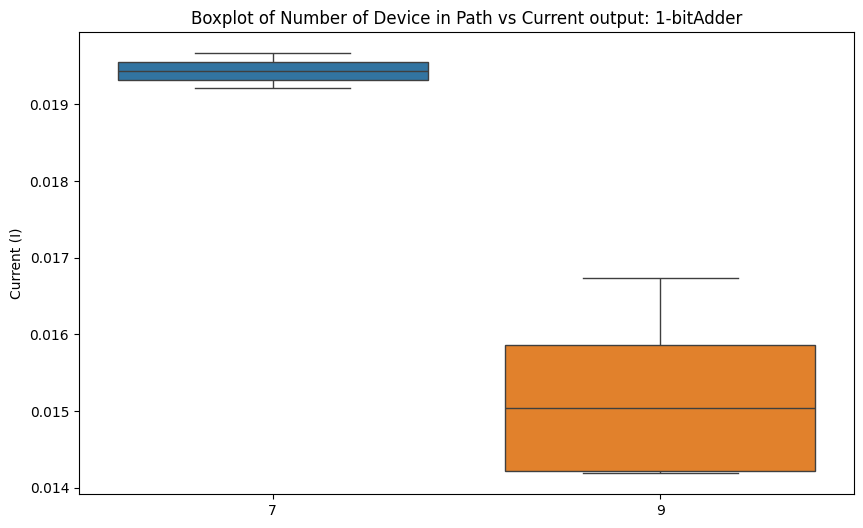

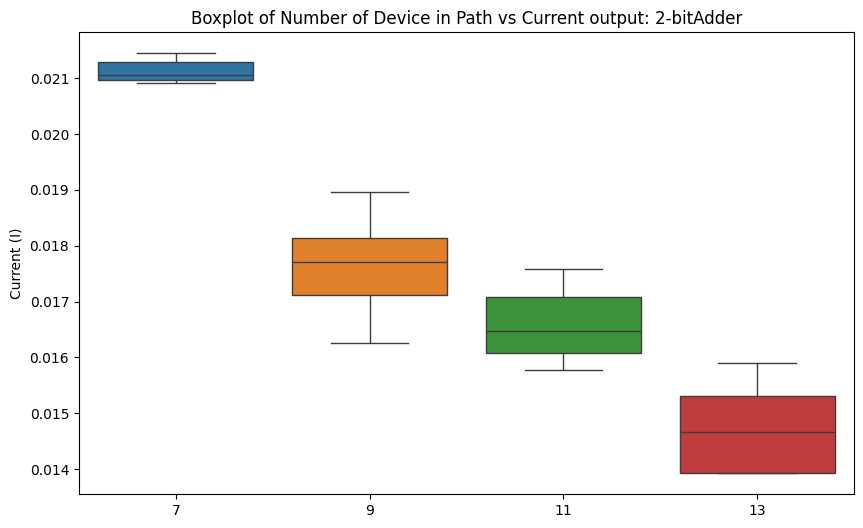

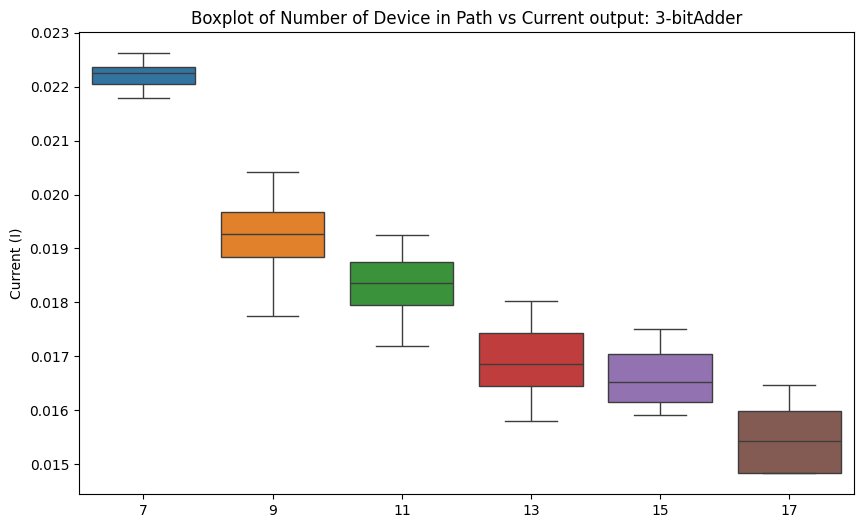

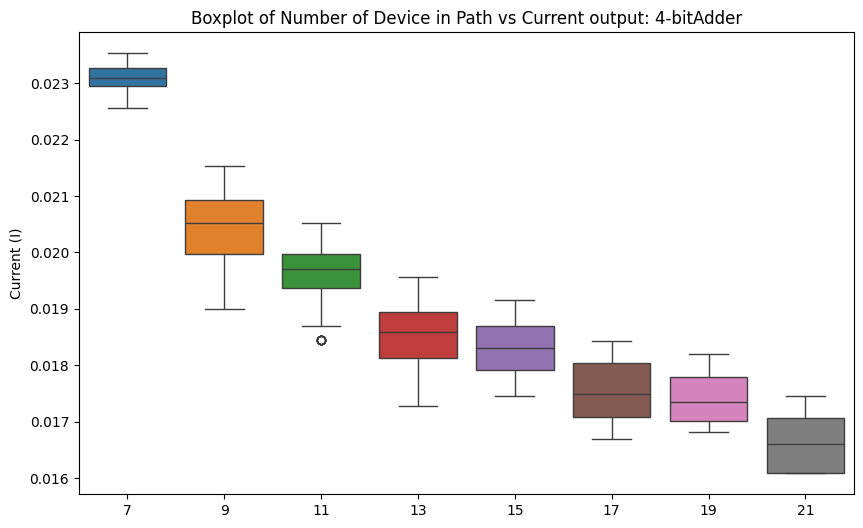

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot_from_sorted_hashmap(data_map, adderBit, sort_keys=True):
    """
    Plots a boxplot (quartile graph) from a hashmap where:
    - Keys are labels for the boxplot.
    - Values are lists of values to be plotted.
    - Sorts the keys before plotting if sort_keys is True.
    """
    # Sort the dictionary by keys if required
    if sort_keys:
        data_map = dict(sorted(data_map.items()))

    # Extract sorted labels and corresponding data
    labels = list(data_map.keys())
    data = list(data_map.values())

    # Create the boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data)
    
    # Set labels
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel("Current (I)")
    plt.title("Boxplot of Number of Device in Path vs Current output: "+adderBit)

    # Show the plot
    plt.show()

for adderBit in Adder_guardbandsVsReistancesDetailsMaps:
    plot_boxplot_from_sorted_hashmap(Adder_guardbandsVsReistancesDetailsMaps[adderBit]['AdderNumDevicesToCurrents_Map'], adderBit)

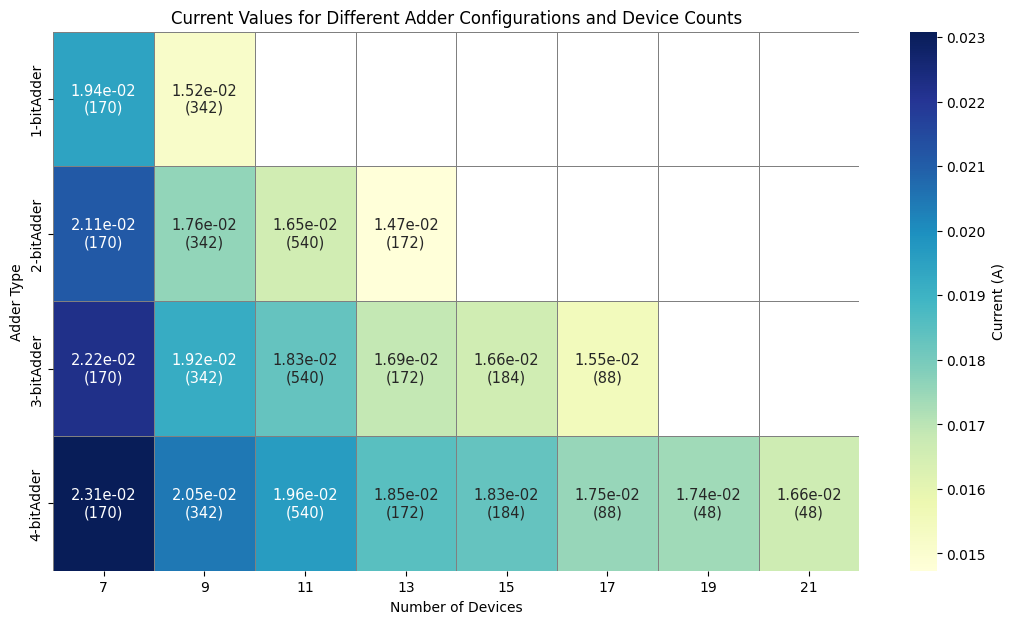

In [52]:
# Extract unique adders and device counts
adders = list(Adder_guardbandsVsReistancesDetailsMaps.keys())
devices = sorted({device for adder in adders for device in Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map'].keys()})

# Create a DataFrame to hold the current values
data = pd.DataFrame(index=adders, columns=devices, dtype=float)

# Create an annotation matrix for the heatmap text
annot_matrix = data.astype(str)

# Populate the DataFrame with current values and create annotation text
for adder in adders:
    for device in devices:
        if device in Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map']:
            current = Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map'][device]
            freqDevices = Adder_guardbandsVsReistancesDetailsMaps[adder]["AdderFrequencyOfNumDevices"][device]

            data.loc[adder, device] = current

            # Formatting annotation with scientific notation for current and frequency on the next line
            annot_matrix.loc[adder, device] = f"{current:.2e}\n({freqDevices})"
        else:
            annot_matrix.loc[adder, device] = ""


# Plotting the heatmap
plt.figure(figsize=(13, 7))
ax = sns.heatmap(data, annot=annot_matrix.values, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Current (A)'},
                 linewidths=0.5, linecolor='gray', annot_kws={"fontsize": 10.5})  # Adjust font size here

# Set labels and title
plt.xlabel('Number of Devices')
plt.ylabel('Adder Type')
plt.title('Current Values for Different Adder Configurations and Device Counts')

# Show the plot
plt.show()

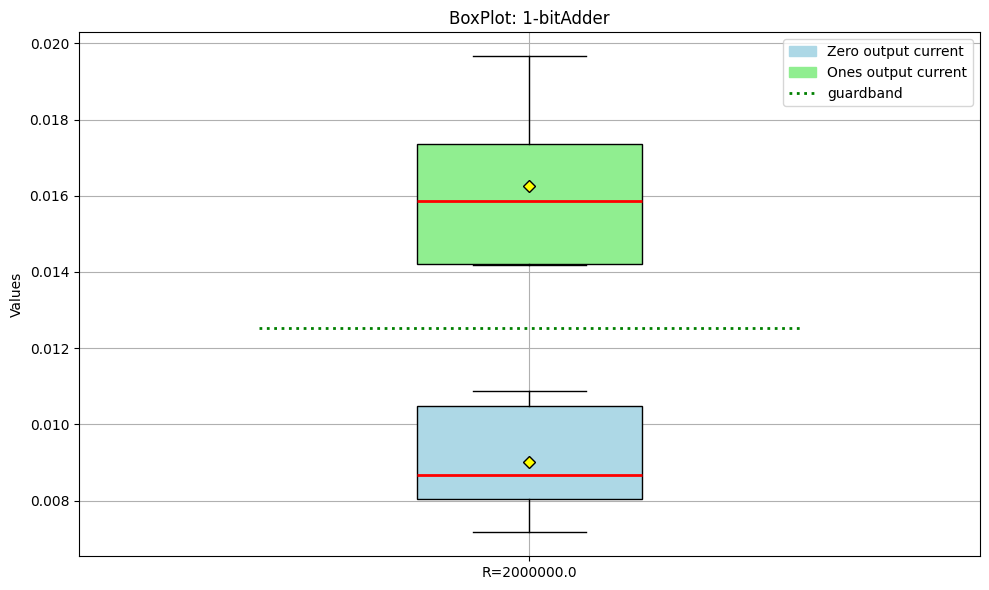

In [104]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


with open("Data/Adder_guardbandsVsReistancesDetailsMaps.pkl", "rb") as f:
    Adder_guardbandsVsReistancesDetailsMaps = pickle.load(f)

Adder_guardbandsVsReistancesDetailsMaps_keys = list(Adder_guardbandsVsReistancesDetailsMaps.keys())
for i in range(len(Adder_guardbandsVsReistancesDetailsMaps_keys)):
    key_adder = Adder_guardbandsVsReistancesDetailsMaps_keys[i]
    Adder_guardbandsVsReistancesDetailsMap = Adder_guardbandsVsReistancesDetailsMaps[key_adder]

    dataZeros = []
    dataOnes = []
    group_labels = []
    
    # Positions for each group
    pos = []
    guardband_values = []

    len_record_details = len(Adder_guardbandsVsReistancesDetailsMap["guardbands"])
    
    for j in range(len_record_details):
        dataZeros.append(Adder_guardbandsVsReistancesDetailsMap["zerosCurrents_lst"][j])
        dataOnes.append(Adder_guardbandsVsReistancesDetailsMap["onesCurrents_lst"][j])
        group_labels.append("R="+str(Adder_guardbandsVsReistancesDetailsMap["resistance_values"][j]))

        guardband_values.append(max(Adder_guardbandsVsReistancesDetailsMap["zerosCurrents_lst"][j])+(Adder_guardbandsVsReistancesDetailsMap["guardbands"][j]/2))
    
        pos.append(j+1)

    if(pos):

        plt.figure(figsize=(10, 6))
    
        
        # Plot dataZeros
        bp_zeros = plt.boxplot(
            dataZeros, 
            positions=pos, 
            patch_artist=True, 
            widths=0.25,             # Adjust width as desired
            showmeans=True,          
            boxprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow')
        )
        
        # Color the boxes (dataZeros)
        for patch in bp_zeros['boxes']:
            patch.set_facecolor('lightblue')
        
        # Plot dataOnes
        bp_ones = plt.boxplot(
            dataOnes, 
            positions=pos, 
            patch_artist=True, 
            widths=0.25,
            showmeans=True,
            boxprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow')
        )
    
        # Add green dotted lines based on each group's guardband value
        for j, guardband_value in enumerate(guardband_values):
            # We'll draw a short line around x_val (from x_val-0.3 to x_val+0.3):
            plt.hlines(
                y=guardband_value,
                xmin=pos[j]-0.3,
                xmax=pos[j]+0.3,
                colors='green',
                linestyles='dotted',
                linewidth=2
            )
        
        # Color the boxes (dataOnes)
        for patch in bp_ones['boxes']:
            patch.set_facecolor('lightgreen')
        
        # Move x-ticks to the midpoint between the two boxplots of each group
        plt.xticks(pos, group_labels)
        
        plt.ylabel("Values")
        plt.title("BoxPlot: "+key_adder)
        plt.grid(True)
        
        # Create legend elements
        zero_patch = mpatches.Patch(color='lightblue', label='Zero output current')
        one_patch = mpatches.Patch(color='lightgreen', label='Ones output current')
        guardband_line = mlines.Line2D([], [], color='green', linestyle='dotted', linewidth=2, label='guardband')
    
        plt.legend(handles=[zero_patch, one_patch, guardband_line], loc='upper right')
        
        plt.tight_layout()
        plt.show()

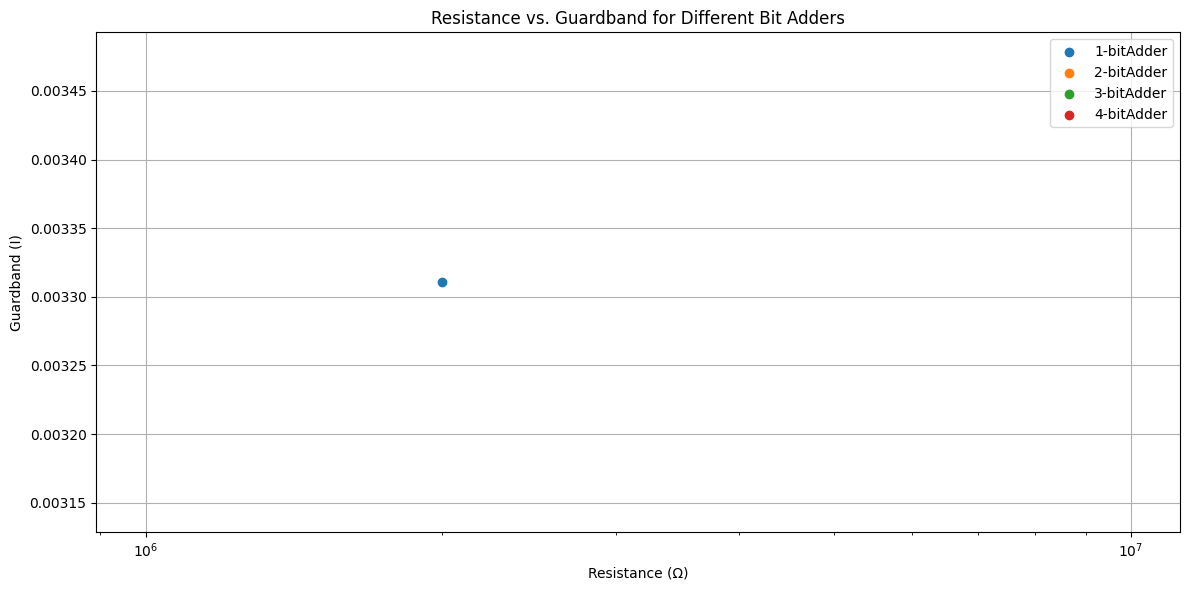

In [105]:
with open("Data/Adder_guardbandsVsReistancesDetailsMaps.pkl", "rb") as f:
    Adder_guardbandsVsReistancesDetailsMaps = pickle.load(f)

plt.figure(figsize=(12, 6))

# A color map or predefined list of colors can be used if you have multiple adders
# For example: colors = plt.cm.tab10(np.linspace(0, 1, len(Adder_guardbandsVsReistancesDetailsMaps)))
# But often letting matplotlib handle defaults is fine.

for i, (adder_name, data) in enumerate(Adder_guardbandsVsReistancesDetailsMaps.items()):
    guardbands = data['guardbands']
    resistances = data['resistance_values']

    
    # Plot them (resistance on x-axis, guardband on y-axis)
    # marker='o' to see points, linestyle='-' to connect them
    plt.scatter(
        resistances, guardbands, 
        marker='o', 
        label=adder_name
    )

plt.xscale('log')  # Often helpful if resistance spans large orders of magnitude
plt.xlabel('Resistance (Ω)')
plt.ylabel('Guardband (I)')
plt.title('Resistance vs. Guardband for Different Bit Adders')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [106]:
# Suppose you have the following lists (all of the same length)
AdderBit = ["1-Bit Adder", "2-Bit Adder", "3-Bit Adder", "4-Bit Adder", "5-Bit Adder"]
SBDDSize = ['13 x 9', '26 x 18', '39 x 27', '52 x 36', '131 x 76']
CrossbarSize = [16, 32, 64, 64, 256]
NumberOfBooleanPermutations = [2, 4, 6, 8, 10]
NumberOfBooleanIterations = [2**2, 2**4, 2**6, 2**8, 2**10]
TimeForEachIterations = [1.5, 8.5, 50, 110, 410]
TotalTimeForEachIterations = [NumberOfBooleanIterations[i]*TimeForEachIterations[i] for i in range(len(NumberOfBooleanIterations))]
TotalTimeInHours = [TotalTimeForEachIterations[i]/3600 for i in range(len(TotalTimeForEachIterations))]
# Put them into a dictionary where each key is the column name,
# and each value is one of the lists:
data = {
    "AdderBit": AdderBit,
    "SBDDSize (V x E)": SBDDSize,
    "CrossbarSize >max(V, E)": CrossbarSize,
    "Number of boolean inputs (n)":NumberOfBooleanPermutations,
    "Total Input permuatations (2^n)":NumberOfBooleanIterations,
    "Time for each boolean input (t)":TimeForEachIterations,
    "Total Time For all boolean inputs ....... T = (t x 2^n)": TotalTimeForEachIterations,
    "Total Time In Hours For Single Binary search iterations of resitance Thr = (T/3600) hours": TotalTimeInHours,
    "Total Iterations (ThrX10) time": [i*10 for i in TotalTimeInHours]
}

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(data)

df

,AdderBit,SBDDSize (V x E),"CrossbarSize >max(V, E)",Number of boolean inputs (n),Total Input permuatations (2^n),Time for each boolean input (t),Total Time For all boolean inputs ....... T = (t x 2^n),Total Time In Hours For Single Binary search iterations of resitance Thr = (T/3600) hours,Total Iterations (ThrX10) time
0,1-Bit Adder,13 x 9,16,2,4,1.5,6.0,0.001667,0.016667
1,2-Bit Adder,26 x 18,32,4,16,8.5,136.0,0.037778,0.377778
2,3-Bit Adder,39 x 27,64,6,64,50.0,3200.0,0.888889,8.888889
3,4-Bit Adder,52 x 36,64,8,256,110.0,28160.0,7.822222,78.222222
4,5-Bit Adder,131 x 76,256,10,1024,410.0,419840.0,116.622222,1166.222222


In [64]:
import numpy as np
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def check_matrix_sparsity_and_efficiency(A, b=None, sparsity_threshold=0.3):
    """
    Checks if a given 2D NumPy matrix A is sparse, based on the ratio of non-zeros.
    If b is given, also compare the runtime of dense vs. sparse solvers.

    Parameters
    ----------
    A : np.matrix or np.ndarray
        The matrix of interest.
    b : np.ndarray or list or None, optional
        The RHS vector for testing linear solving.
        If None, no solver timing is performed.
    sparsity_threshold : float
        If non_zero_ratio < sparsity_threshold, we classify the matrix as "sparse".

    Returns
    -------
    None
    """

    # Ensure A is a NumPy array
    A_arr = np.array(A, dtype=float)  # convert np.matrix to np.ndarray if needed

    print("Matrix dimentions (m x m):", A_arr.shape)
    
    # 1) Check the sparsity ratio
    total_elements = A_arr.size
    nonzero_elements = np.count_nonzero(A_arr)
    nonzero_ratio = nonzero_elements / total_elements
    zero_ratio = 1.0 - nonzero_ratio

    print("=== Sparsity Check ===")
    print(f"Matrix shape: {A_arr.shape}")
    print(f"Total elements: {total_elements}")
    print(f"Non-zero elements: {nonzero_elements}")
    print(f"Non-zero ratio: {nonzero_ratio:.2f}  ({nonzero_ratio*100:.2f} %)")
    print(f"Zero ratio: {zero_ratio:.2f}        ({zero_ratio*100:.2f} %)")

    if nonzero_ratio < sparsity_threshold:
        print("Matrix is considered SPARSE based on the given threshold.")
    else:
        print("Matrix is NOT considered sparse based on the given threshold.")

    # 2) (Optional) Compare efficiency of dense vs. sparse solver
    if b is not None:
        print("\n=== Solver Efficiency Check ===")
        
        # Ensure b is a 1D array
        b_arr = np.array(b, dtype=float).ravel()

        # Dense solve timing
        start_time = time.time()
        x_dense = np.linalg.solve(A_arr, b_arr)
        dense_time = time.time() - start_time

        # Sparse solve timing
        A_csr = sp.csr_matrix(A_arr)
        start_time = time.time()
        x_sparse = spla.spsolve(A_csr, b_arr)
        sparse_time = time.time() - start_time

        print(f"Dense solve time  : {dense_time:.6f} seconds")
        print(f"Sparse solve time : {sparse_time:.6f} seconds")

        # (Optional) Compare solutions
        diff = np.linalg.norm(x_dense - x_sparse, ord=2)
        print(f"Difference between dense and sparse solutions: {diff:.2e}")

    print("\nDone.\n")


# ======================
# Example usage:
# ======================
if __name__ == "__main__":
    # Example 1: A small "sparse" matrix
    A_example_1 = AnalogPathTest.tempMatrix[0]
    b_example_1 = AnalogPathTest.tempMatrix[1]

    check_matrix_sparsity_and_efficiency(A_example_1, b_example_1, sparsity_threshold=0.2)

Matrix dimentions (m x m): (128, 128)
=== Sparsity Check ===
Matrix shape: (128, 128)
Total elements: 16384
Non-zero elements: 8256
Non-zero ratio: 0.50  (50.39 %)
Zero ratio: 0.50        (49.61 %)
Matrix is NOT considered sparse based on the given threshold.

=== Solver Efficiency Check ===
Dense solve time  : 0.000000 seconds
Sparse solve time : 0.001999 seconds
Difference between dense and sparse solutions: 8.72e-15

Done.

